In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\cleaned_data.csv")
print(f"Data loaded ✅ Shape: {df.shape}")

Data loaded ✅ Shape: (289, 43)


In [3]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print("Style set ✅")

Style set ✅


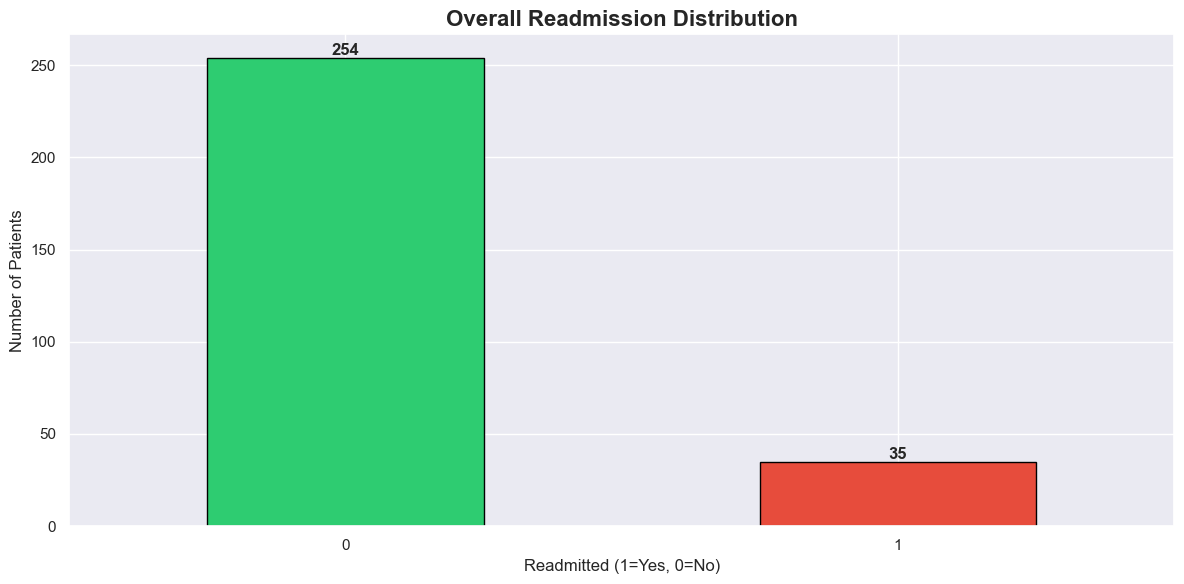

In [4]:
colors = ['#2ecc71', '#e74c3c']
ax = df['readmitted'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Overall Readmission Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Readmitted (1=Yes, 0=No)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\01_readmission_distribution.png", dpi=150)
plt.show()

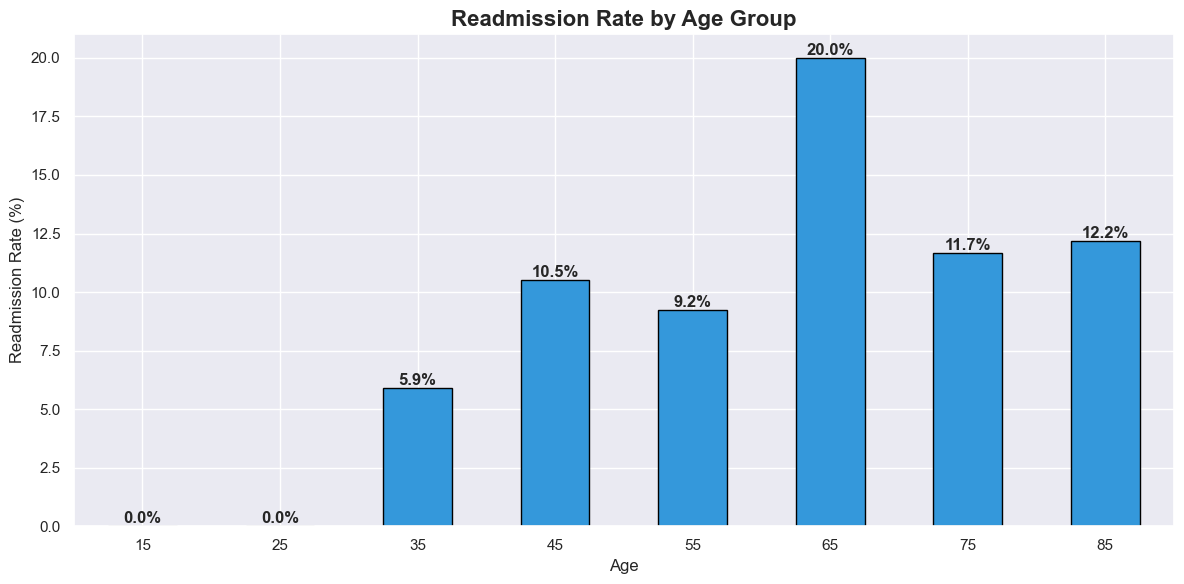

In [5]:
age_readmit = df.groupby('age')['readmitted'].mean() * 100
ax = age_readmit.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Readmission Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\02_readmission_by_age.png", dpi=150)
plt.show()

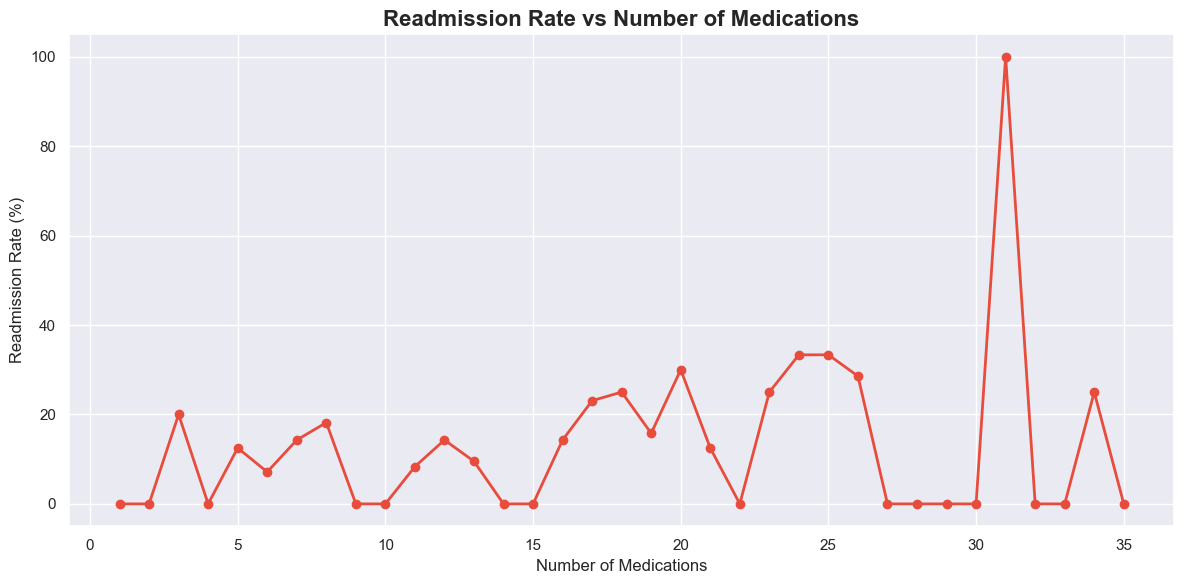

In [6]:
med_readmit = df.groupby('num_medications')['readmitted'].mean() * 100
plt.plot(med_readmit.index, med_readmit.values, color='#e74c3c', linewidth=2, marker='o')
plt.title('Readmission Rate vs Number of Medications', fontsize=16, fontweight='bold')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\03_medications_vs_readmission.png", dpi=150)
plt.show()

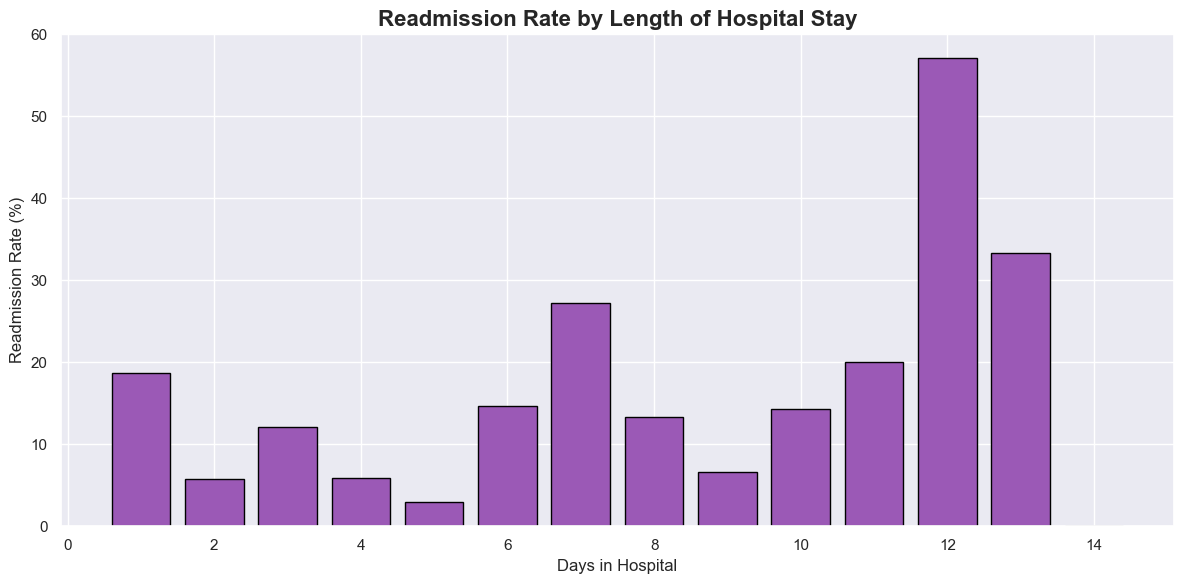

In [7]:
stay_readmit = df.groupby('time_in_hospital')['readmitted'].mean() * 100
plt.bar(stay_readmit.index, stay_readmit.values, color='#9b59b6', edgecolor='black')
plt.title('Readmission Rate by Length of Hospital Stay', fontsize=16, fontweight='bold')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\04_hospital_stay_vs_readmission.png", dpi=150)
plt.show()

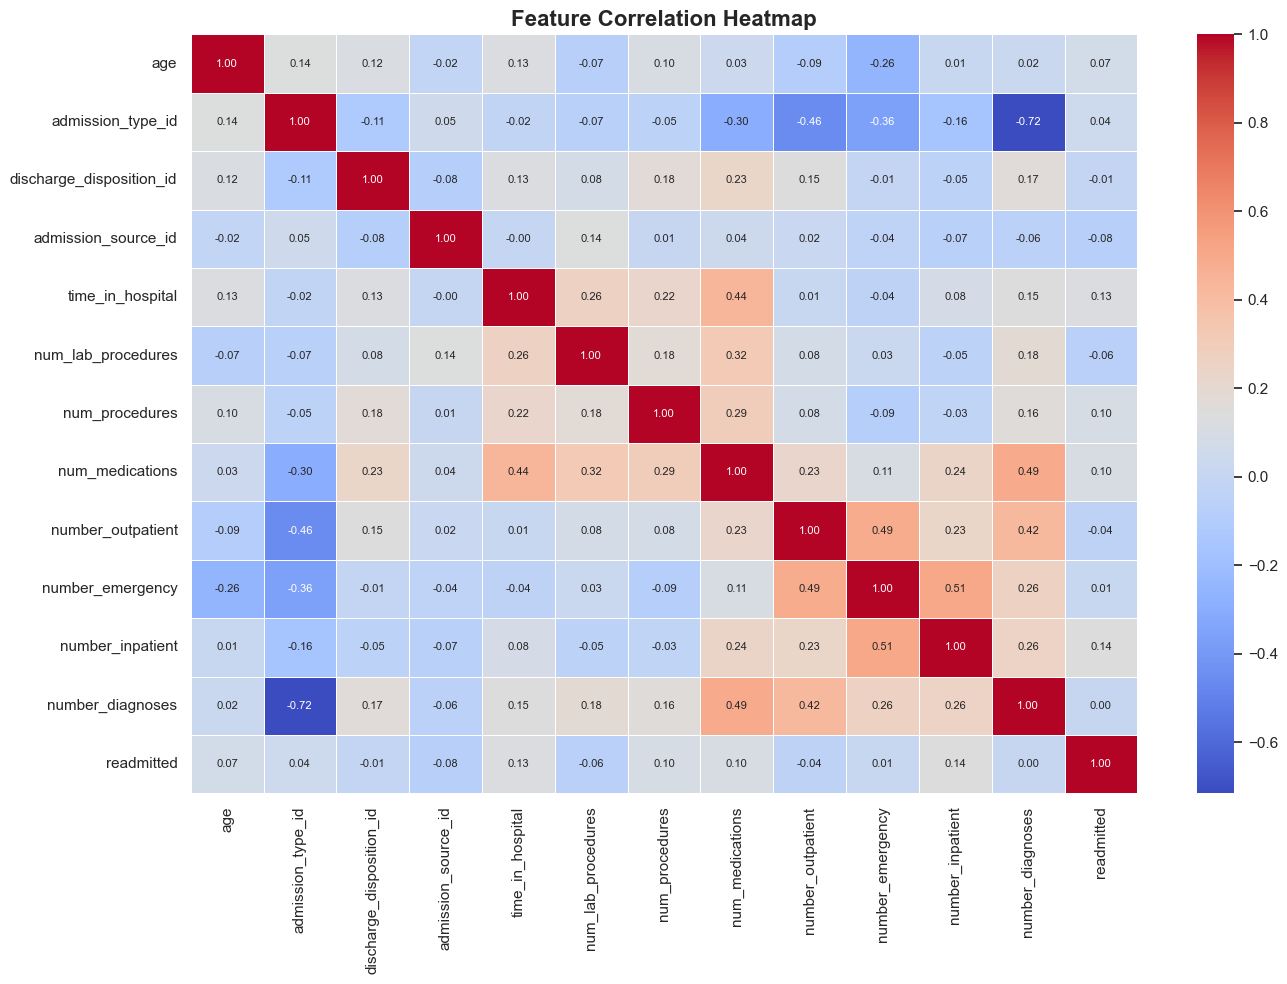

In [8]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\05_correlation_heatmap.png", dpi=150)
plt.show()